# Aeroscapes Semantic Segmentation — Methods & Results

Companion notebook to [`docs/REPORT.md`](../docs/REPORT.md). Sections:

1. reference solutions we reviewed,
2. our two training setups (Dice+CE for imbalance, stronger backbone for mIoU),
3. logged results and plots,
4. qualitative examples on hard classes (obstacle / bike / animal).

Run top-to-bottom. Section 3 needs only `docs/assets/run_history.json`. Section 4
also loads checkpoints from `logs/` and masks from `data/aeroscapes/`; if either
is missing, it prints a message and skips the figure.

In [1]:
# --- setup: resolve project root, imports, load logged metrics ---
import os, json
from pathlib import Path

# Run from the project root regardless of where the kernel started (matches eda.ipynb).
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
os.chdir(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["figure.dpi"] = 110

HIST = json.load(open("docs/assets/run_history.json"))
CLASS_NAMES = HIST["class_names"]
FG = list(range(1, 12))                      # foreground classes (0 = background, ignored)
RUNS = HIST["runs"]
ORDER = ["baseline_r50_ce", "A_dice_r50", "B_best_r101"]
COLORS = {"baseline_r50_ce": "#888888", "A_dice_r50": "#1f77b4", "B_best_r101": "#d62728"}
for k in ORDER:
    r = RUNS[k]
    print(f"{r['label']:24s}  best val mIoU = {r['best_val_miou']:.3f}  @ epoch {r['best_epoch']}")

Baseline CE (r50)         best val mIoU = 0.672  @ epoch 22
A: Dice+CE (r50)          best val mIoU = 0.709  @ epoch 8
B: r101 COCO+Dice+CE      best val mIoU = 0.694  @ epoch 21


## 1. Reference solutions (`docs/proposal_solutions/`)

We surveyed 11 Kaggle notebooks. Half of them target a different problem (whole-image
classification or person detection) and report accuracy, not mIoU.

**Semantic segmentation** (comparable to our task):

| Notebook | Architecture | Loss | Resolution | Classes | mIoU |
|---|---|---|---|---|---|
| `pytorch-...-miou-0-94-deeplabv3` | DeepLabV3+ / DPN107 | CE | **256×256** resize | 11 (no bg) | ≈ 0.93 |
| `pytorch-...-miou-0-93-deeplabv3` | DeepLabV3+ / ResNet34 | CE | **256×256** resize | 11 (no bg) | ≈ 0.85–0.87 |
| `aerial-semantic-segmentation` | U-Net / MobileNetV2 | CE | downsampled | 10 | 0.707 |
| `4task` | U-Net (+DeepLabV3+) | Focal+Dice+Jaccard | varies | — | ≈ 0.74¹ |
| `uav-aerial-segmentation-with-unet` | U-Net (scratch) | Dice+CE | downsampled | — | no mIoU (Dice≈0.40) |
| `semantic-segmentation-tutorial-tf` | U-Net / EfficientNetB3 | Focal+Dice | downsampled | — | 0.198² |

¹ 200-image subset, non-standard IoU. ² short demo run.

**Classification / detection** (mIoU not applicable): EfficientNet ~98%, YOLOv8 74%, etc.

The highest segmentation scores (~0.93) come from a strong encoder (DPN107) and plain
CE, without explicit imbalance handling — but also at **256×256** and with **11 output
classes** (background omitted from the model). We validate at **native 1280×720**
(512 px crops in training) with `ignore_index=0`, so the headline numbers above are
only loosely comparable.

## 2. Our two methods

Same training pipeline throughout; the only new code is the loss in
[`src/models/losses.py`](../src/models/losses.py).

| | Method A | Method B |
|---|---|---|
| Config | [`deeplabv3_dice_aeroscapes.py`](../src/config/deeplabv3_dice_aeroscapes.py) | [`deeplabv3_resnet101_best_aeroscapes.py`](../src/config/deeplabv3_resnet101_best_aeroscapes.py) |
| Backbone | DeepLabV3-ResNet50 (ImageNet) | DeepLabV3-ResNet101 (COCO) |
| Loss | Dice + weighted CE | same |
| Training | **512×512** random crops | **512×512** random crops |
| Validation | **1280×720** (native) | **1280×720** (native) |
| mIoU | 11 foreground classes, `ignore_index=0` | same |

**Method A** targets class imbalance. Architecture matches the CE baseline; only the
loss changes to `DiceCELoss = weighted CE + Dice`. CE is pixel-weighted, so rare classes
barely affect the gradient. Dice averages per-class overlap, giving small objects
comparable influence to large ones.

**Method B** targets overall mIoU: ResNet101, full COCO pretraining, the same Dice+CE
loss as A, and a cosine LR schedule. Capacity and pretraining differ; the loss does not.

## 3. Results

Best-epoch validation mIoU (checkpoint selection metric), 11 foreground classes,
full-resolution 1280×720 validation.

In [2]:
# --- 3a. headline table ---
print(f"{'run':28s} {'best mIoU':>10} {'best epoch':>11}")
print("-"*52)
for k in ORDER:
    r = RUNS[k]
    print(f"{r['label']:28s} {r['best_val_miou']:>10.3f} {r['best_epoch']:>11d}")
base = RUNS['baseline_r50_ce']['best_val_miou']
print()
for k in ["A_dice_r50", "B_best_r101"]:
    print(f"{RUNS[k]['label']}: {RUNS[k]['best_val_miou']-base:+.3f} vs baseline")

run                           best mIoU  best epoch
----------------------------------------------------
Baseline CE (r50)                 0.672          22
A: Dice+CE (r50)                  0.709           8
B: r101 COCO+Dice+CE              0.694          21

A: Dice+CE (r50): +0.037 vs baseline
B: r101 COCO+Dice+CE: +0.022 vs baseline


Swapping the loss alone (Method A) gave the largest gain (**+0.037 mIoU**) and
briefly outperformed the heavier ResNet101 setup. On this dataset, the Dice term
mattered more than adding model capacity.

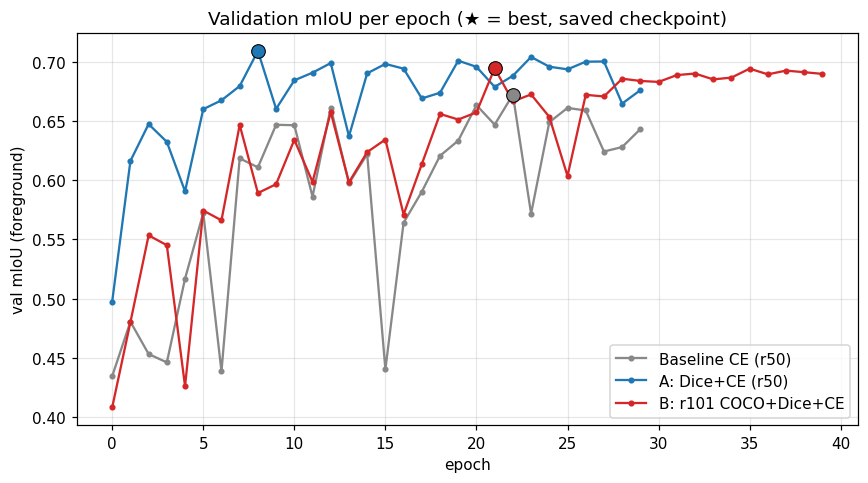

In [3]:
# --- val mIoU per epoch ---
plt.figure(figsize=(8, 4.5))
for k in ORDER:
    s = RUNS[k]["series"]
    plt.plot(s["epoch"], s["val_miou"], label=RUNS[k]["label"], color=COLORS[k], marker="o", ms=3)
    bi = s["val_miou"].index(RUNS[k]["best_val_miou"])
    plt.scatter([s["epoch"][bi]], [s["val_miou"][bi]], color=COLORS[k], s=80, zorder=5,
                edgecolor="k", linewidth=0.7)
plt.xlabel("epoch"); plt.ylabel("val mIoU (foreground)")
plt.title("Validation mIoU per epoch (★ = best, saved checkpoint)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

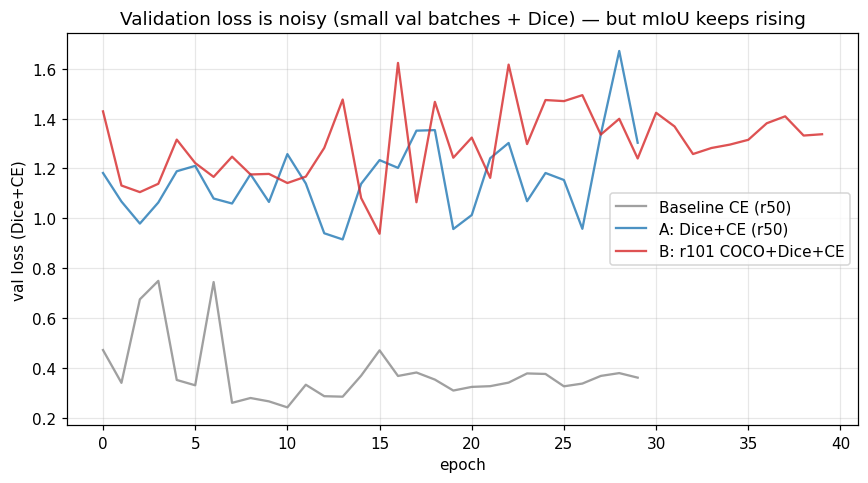

In [4]:
# --- val loss per epoch: shows the 'loss goes up' wobble is NOISE ---
plt.figure(figsize=(8, 4.5))
for k in ORDER:
    s = RUNS[k]["series"]
    plt.plot(s["epoch"], s["val_loss"], label=RUNS[k]["label"], color=COLORS[k], alpha=0.8)
plt.xlabel("epoch"); plt.ylabel("val loss (Dice+CE)")
plt.title("Validation loss is noisy (small val batches + Dice) — but mIoU keeps rising")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

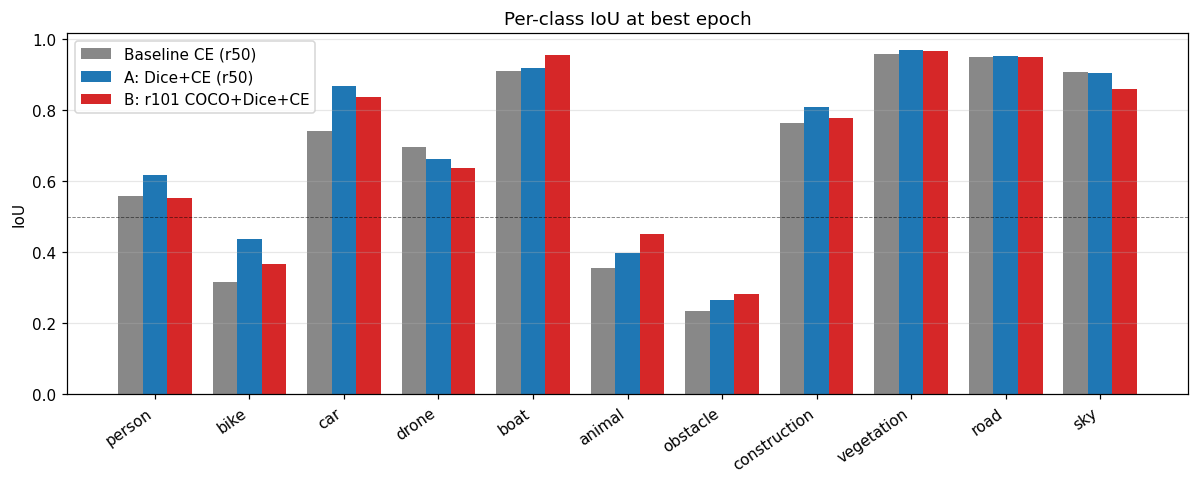

In [5]:
# --- 3b. per-class IoU at each run's best epoch (grouped bars) ---
x = np.arange(len(FG)); w = 0.26
plt.figure(figsize=(11, 4.5))
for i, k in enumerate(ORDER):
    vals = [RUNS[k]["best_per_class"][CLASS_NAMES[c]] for c in FG]
    plt.bar(x + (i-1)*w, vals, w, label=RUNS[k]["label"], color=COLORS[k])
plt.xticks(x, [CLASS_NAMES[c] for c in FG], rotation=35, ha="right")
plt.ylabel("IoU"); plt.title("Per-class IoU at best epoch")
plt.axhline(0.5, color="k", ls="--", lw=0.6, alpha=0.5)
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

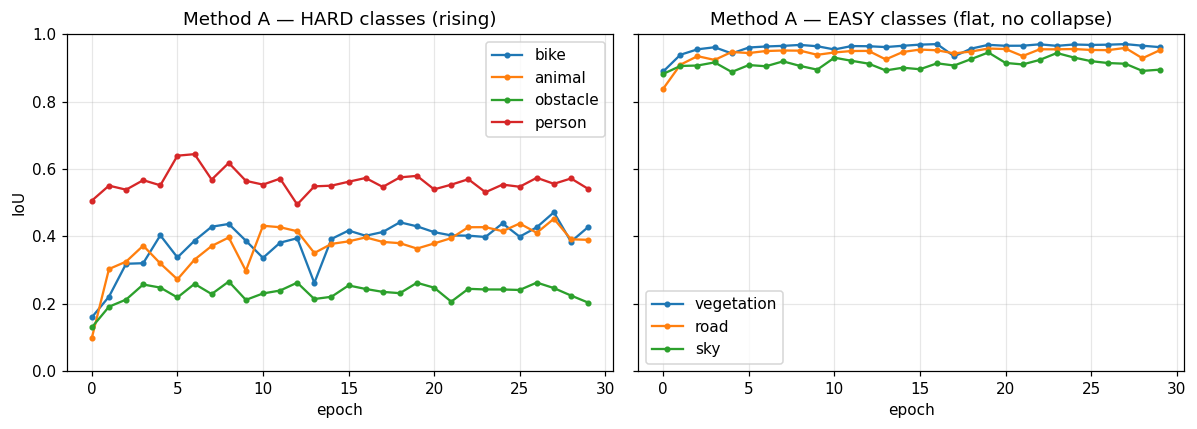

In [6]:
# --- easy classes stay stable while hard classes climb (Method A) ---
s = RUNS["A_dice_r50"]["series"]
hard = {"bike": 2, "animal": 6, "obstacle": 7, "person": 1}
easy = {"vegetation": 9, "road": 10, "sky": 11}
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for name, c in hard.items():
    ax[0].plot(s["epoch"], s[f"iou_{c}"], marker="o", ms=3, label=name)
ax[0].set_title("Method A — HARD classes (rising)"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("IoU")
ax[0].legend(); ax[0].grid(alpha=0.3)
for name, c in easy.items():
    ax[1].plot(s["epoch"], s[f"iou_{c}"], marker="o", ms=3, label=name)
ax[1].set_title("Method A — EASY classes (flat, no collapse)"); ax[1].set_xlabel("epoch")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Reading the plots**

- Hard classes improve but remain well below road/vegetation (~0.95). At Method A's
  best epoch: obstacle 0.235→0.266, bike 0.316→0.437, animal 0.355→0.397. Method B
  does better on obstacle/animal (0.284 / 0.451) at some cost to bike and person.
- Easy classes stay stable — the right-hand panel is nearly flat. Early val-loss
  spikes are batch noise (small val set + Dice), not a real regression; trust
  per-class IoU over loss alone.
- Background is excluded from metrics (`ignore_index=0`); see section 4 for how
  that shows up visually.
- The two models excel on different classes (A: person/bike/car; B: obstacle/animal),
  which motivates the fusion idea in section 5.

## 4. Qualitative analysis — why the hard classes are hard

We run both checkpoints on validation images that contain obstacle, bike, or animal
and compare predictions side by side. Requires checkpoints in `logs/` and the dataset
under `data/aeroscapes/`.

**Background (black in GT).** Class 0 is excluded from both loss and mIoU
(`ignore_index=0`; references use the same convention with 11 scored classes). The
network still has 12 outputs, but receives no gradient on GT-background pixels, so
predictions often contain no black at all — those regions get assigned to foreground
classes instead. That can look wrong on the figure, but those pixels are not included
in val mIoU.

In [7]:
# --- load both trained models from their Fiddle configs + checkpoints ---
import glob, torch
import fiddle as fdl
from src.utils.config import parse_fiddle_config

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def find_ckpt(prefix):
    dirs = sorted(glob.glob(f"logs/{prefix}*"))
    if not dirs:
        return None
    d = dirs[-1]
    best = sorted(glob.glob(f"{d}/epoch=*.ckpt"))
    if best:
        return best[0]
    last = f"{d}/last.ckpt"
    return last if os.path.exists(last) else None

def load_model(cfg_path, ckpt_path):
    model = fdl.build(parse_fiddle_config(cfg_path)).model
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)["state_dict"]
    model.load_state_dict(state)
    return model.eval().to(DEVICE)

MODELS = {}
specs = {
    "A (Dice+CE r50)":  ("src/config/deeplabv3_dice_aeroscapes.py",            "deeplabv3_resnet50_dice"),
    "B (r101 COCO)":    ("src/config/deeplabv3_resnet101_best_aeroscapes.py",  "deeplabv3_resnet101_best"),
}
for label, (cfg, prefix) in specs.items():
    ck = find_ckpt(prefix)
    if ck:
        MODELS[label] = load_model(cfg, ck)
        print(f"loaded {label}  <-  {ck}")
    else:
        print(f"!! no checkpoint for {label} (prefix logs/{prefix}*) — skipping")
print("device:", DEVICE)

loaded A (Dice+CE r50)  <-  logs/deeplabv3_resnet50_dice_aeroscapes_20260605_224330/epoch=8-step=2952.ckpt
loaded B (r101 COCO)  <-  logs/deeplabv3_resnet101_best_aeroscapes_20260606_012259/epoch=21-step=14410.ckpt
device: cuda


In [8]:
# --- palette + helpers ---
from PIL import Image
from src.datasets.aeroscapes import build_eval_transforms
from src.config.aeroscapes_constants import IMAGENET_MEAN, IMAGENET_STD

# 12 visually distinct colors (index = class id). Used for BOTH gt and pred.
PALETTE = np.array([
    (0, 0, 0),       (220, 20, 60),   (0, 200, 0),     (0, 120, 255),
    (255, 215, 0),   (160, 32, 240),  (255, 140, 0),   (0, 230, 230),
    (139, 69, 19),   (34, 139, 34),   (190, 190, 190), (135, 206, 250),
], dtype=np.uint8)

def colorize(mask):
    return PALETTE[np.asarray(mask)]

def per_class_iou(pred, gt, c):
    p, g = (pred == c), (gt == c)
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    return float(inter / union) if union else float("nan")

EVAL_TF = build_eval_transforms()  # native res + ImageNet normalize
IMG_DIR = Path("data/aeroscapes/JPEGImages")
MASK_DIR = Path("data/aeroscapes/SegmentationClass")
VAL_STEMS = Path("data/aeroscapes/ImageSets/val.txt").read_text().split()

@torch.no_grad()
def predict(model, stem):
    import torchvision.tv_tensors as tv
    import torchvision.transforms.v2.functional as v2F
    img = tv.Image(v2F.pil_to_tensor(Image.open(IMG_DIR / f"{stem}.jpg").convert("RGB")))
    mask = tv.Mask(np.array(Image.open(MASK_DIR / f"{stem}.png")))
    x, _ = EVAL_TF(img, mask)
    logits = model(x.unsqueeze(0).to(DEVICE))
    return logits.argmax(1)[0].cpu().numpy()

print("helpers ready; val images:", len(VAL_STEMS))

helpers ready; val images: 648


In [9]:
# --- pick val images that contain hard classes (obstacle / bike / animal) ---
HARD = {"bike": 2, "animal": 6, "obstacle": 7}
MIN_PIX = 400  # ignore trace amounts so the example is meaningful

picks, used = [], set()
# first: one example per hard class (if available)
for name, c in HARD.items():
    for stem in VAL_STEMS:
        if stem in used:
            continue
        gt = np.array(Image.open(MASK_DIR / f"{stem}.png"))
        if (gt == c).sum() <= MIN_PIX:
            continue
        present = [n for n, cn in HARD.items() if (gt == cn).sum() > MIN_PIX]
        picks.append((stem, present))
        used.add(stem)
        break
# then: fill to 4 with any other hard-class scenes
for stem in VAL_STEMS:
    if len(picks) >= 4:
        break
    if stem in used:
        continue
    gt = np.array(Image.open(MASK_DIR / f"{stem}.png"))
    present = [n for n, c in HARD.items() if (gt == c).sum() > MIN_PIX]
    if present:
        picks.append((stem, present))
        used.add(stem)
print("selected:", [(s, p) for s, p in picks])

selected: [('002000_001', ['obstacle']), ('002000_002', ['obstacle']), ('002000_003', ['obstacle']), ('002000_004', ['obstacle'])]


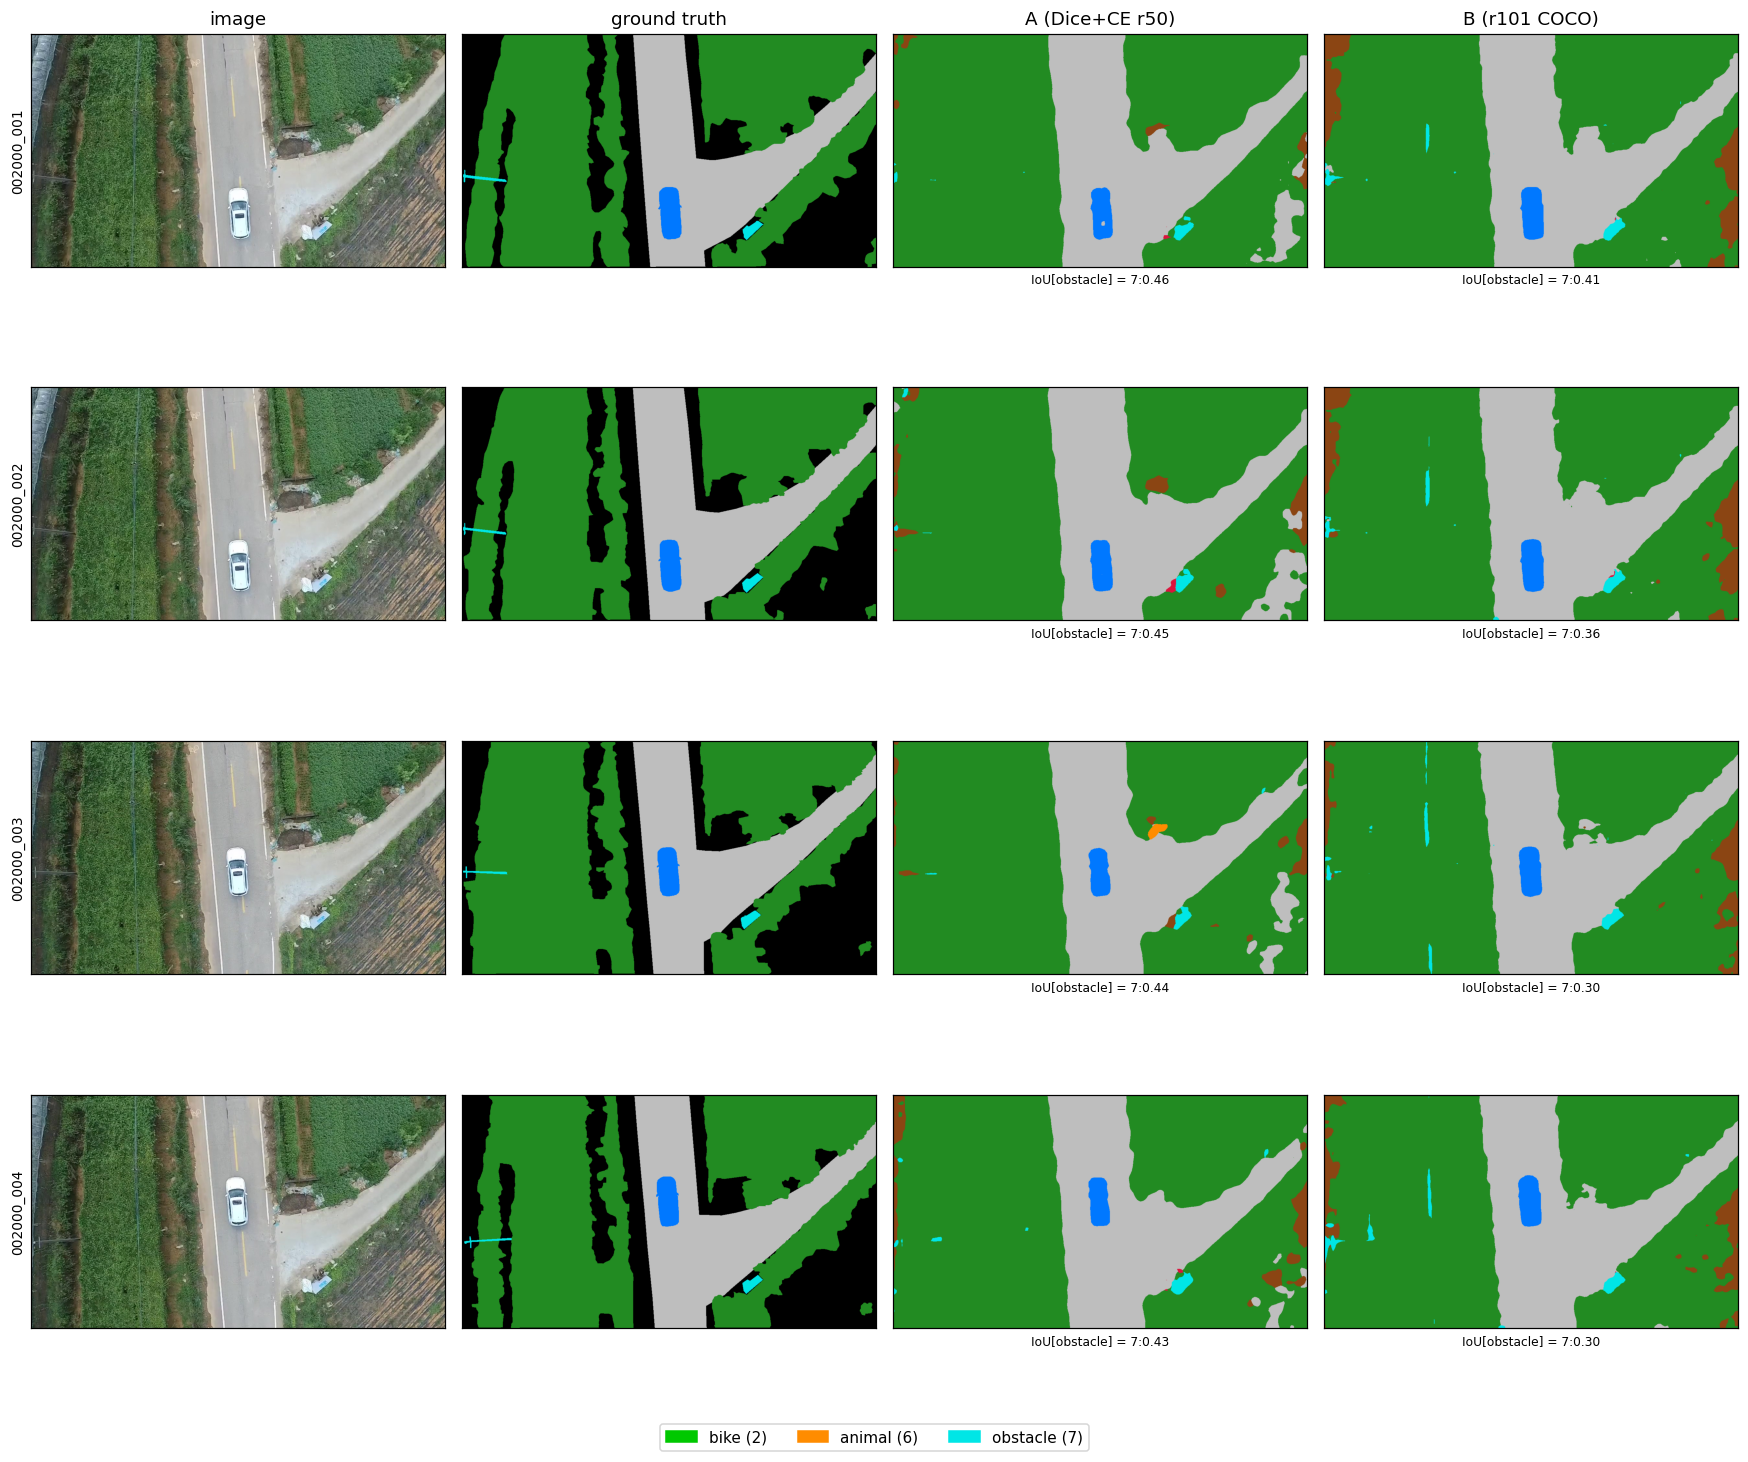

In [ ]:
# --- side-by-side: image | ground truth | Method A | Method B (+ hard-class IoU) ---
if MODELS and picks:
    n = len(picks)
    cols = 2 + len(MODELS)
    fig, axes = plt.subplots(n, cols, figsize=(4*cols, 3.4*n))
    if n == 1:
        axes = axes[None, :]

    # legend: classes actually present in the selected GT masks
    legend_classes = sorted({
        c
        for stem, _ in picks
        for c in range(len(CLASS_NAMES))
        if (np.array(Image.open(MASK_DIR / f"{stem}.png")) == c).sum() > MIN_PIX
    })

    for r, (stem, present) in enumerate(picks):
        gt = np.array(Image.open(MASK_DIR / f"{stem}.png"))
        raw = Image.open(IMG_DIR / f"{stem}.jpg").convert("RGB")
        axes[r, 0].imshow(raw); axes[r, 0].set_ylabel(stem, fontsize=9)
        axes[r, 0].set_title("image" if r == 0 else "")
        axes[r, 1].imshow(colorize(gt)); axes[r, 1].set_title("ground truth" if r == 0 else "")
        for j, (label, model) in enumerate(MODELS.items()):
            pred = predict(model, stem)
            ious = "  ".join(f"{p}:{per_class_iou(pred, gt, HARD[p]):.2f}" for p in present)
            axes[r, 2+j].imshow(colorize(pred))
            axes[r, 2+j].set_title(f"{label}" if r == 0 else "")
            axes[r, 2+j].set_xlabel(f"IoU[{', '.join(present)}] = {ious}", fontsize=8)
        for a in axes[r]:
            a.set_xticks([]); a.set_yticks([])

    handles = [
        mpatches.Patch(color=PALETTE[c]/255, label=f"{CLASS_NAMES[c]} ({c})")
        for c in legend_classes
    ]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 6), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(); plt.show()
else:
    print("No models or no matching images — skipping qualitative figure.")

**What stands out in the images**

- **Small, thin objects.** Bikes and obstacles span only a few pixels; a single-pixel
  boundary shift costs a large fraction of IoU even when the mask looks reasonable.
- **Vague class boundary.** *Obstacle* covers poles, rocks, debris, fences — little
  shared appearance. Low IoU here reflects ambiguous labels as much as frequency.
- **Scale range.** Altitude varies widely, so the same object type can occupy very
  different pixel counts; small instances are easy to lose after downsampling.

The two models often err on different parts of the same scene (see per-class IoU
under each column), matching the complementarity in the bar chart above.

## 5. Next steps for the hard classes

1. **Larger crops / higher resolution** — most direct way to preserve thin objects;
   limited by GPU memory.
2. **Loss tuning** — increase `dice_weight`, or add Focal loss for hard pixels;
   [`losses.py`](../src/models/losses.py) is set up to extend.
3. **Copy-paste augmentation** for bike / obstacle / animal — more training exposure
   at usable pixel scale without waiting for rare scenes.
4. **Two-model fusion (longer term).** Train a hard-class specialist (strong Dice +
   class weights, accepting weaker easy classes) and combine it with the generalist
   run — e.g. per-class confidence or a lightweight router. Methods A and B already
   win on different classes, so there is room to merge their strengths.